## IMPORTS

In [9]:
# Auto reload modules
%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm

from weac.components import Segment, ScenarioConfig, WeakLayer, CriteriaConfig, WEAK_LAYER
from weac.analysis import CriteriaEvaluator
from weac.utils.snowpilot_parser import convert_to_mm, convert_to_deg

from layerwise.analysis.profile_utils import load_snowpilot_parsers, eval_avalanche_pit

## SETTINGS

In [11]:
## Settings
run_weac = True
dev = True
discard_pits_with_wl_above = 50 # mm

## Setup standard values

raw_data_dir = "../data/raw/slf-rb"
csv_file = "../data/misc/weac_over_slf_rb.csv"


## PARSE SNOWPYLOT

In [12]:
## Parse all snowpilot files near an avalanche and a layer of concern

paths, parsers = load_snowpilot_parsers(raw_data_dir)

print(f"Overall number of files: {len(paths)}")

paths_and_parsers = [
    (fp, pars)
    for fp, pars in zip(paths, parsers)
]

Overall number of files: 13276


In [13]:
different_rb_scores = set(
    rb.test_score
    for fp, pars in paths_and_parsers
    for rb in pars.snowpit.stability_tests.RBlock
)

different_rb_fracture_character = set(
    rb.fracture_character
    for fp, pars in paths_and_parsers
    for rb in pars.snowpit.stability_tests.RBlock
)

different_rb_release_type = set(
    rb.release_type
    for fp, pars in paths_and_parsers
    for rb in pars.snowpit.stability_tests.RBlock
)

print(len(paths_and_parsers))
print(len(different_rb_scores), different_rb_scores)
print(len(different_rb_fracture_character), different_rb_fracture_character)
print(len(different_rb_release_type), different_rb_release_type)

13276
7 {None, 'RB2', 'RB6', 'RB3', 'RB5', 'RB1', 'RB4'}
4 {None, 'Rough', 'Irregular', 'Clean'}
4 {'EB', None, 'WB', 'MB'}


## EXTRACT INFO

Extract Depth at which the weak layer should be inserted.

In this case: Depth of ECT Result

In [14]:
# Extract additional pit information

pit_info_list = []
unique_rb_entries = []
for i,(fp, pit) in enumerate(paths_and_parsers):
    if i % 100 == 0:
        print(f"Processing pit {i} of {len(paths_and_parsers)}")
    for rb in pit.snowpit.stability_tests.RBlock:
        try:
            hs = pit.snowpit.snow_profile.hs
            if hs:
                hs_mm = hs[0] * convert_to_mm[hs[1]]
            else:
                hs_mm = None
            profile_depth = pit.snowpit.snow_profile.profile_depth
            if profile_depth:
                profile_depth_mm = profile_depth[0] * convert_to_mm[profile_depth[1]]
            else:
                profile_depth_mm = None
            depth_top_mm = rb.depth_top[0] * convert_to_mm[rb.depth_top[1]]
            test_score = rb.test_score
            fracture_character = rb.fracture_character
            release_type = rb.release_type
            slope_angle = pit.snowpit.core_info.location.slope_angle
            if slope_angle:
                slope_angle_deg = slope_angle[0] * convert_to_deg[slope_angle[1]]
            else:
                slope_angle_deg = 0.0
            pit_info_dict = {
                "Slope Angle": slope_angle_deg,
                "HS": hs_mm,
                "Profile Depth": profile_depth_mm,
                "WL_Depth": depth_top_mm,
                "RBlock_Score": test_score,
                "RBlock_Fracture_Character": fracture_character,
                "RBlock_Release_Type": release_type,
            }
            unique_rb_entries.append(pit)
            pit_info_list.append(pit_info_dict)
        except Exception as e:
            print(f"{e} Skipping pit {fp}")
print(len(unique_rb_entries))

Processing pit 0 of 13276
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/10f3ada0-407a-439b-b67f-3bc990f011ca.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/0dd96bb5-0234-453e-b5c5-57bdebcd3d65.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/d8359774-7aa6-4302-b989-99d91242bdcb.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/73bc79c5-6acb-4715-a0d7-9e224322f461.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/895af690-51ff-4146-8edf-dc94ff36ac3d.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/047073ae-106b-4c61-9d44-293b88911eaa.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/7d62c1ba-3502-433e-bd99-7e3ecc0bb903.caaml.xml
'NoneType' object is not subscriptable Skipping pit ../data/raw/slf-rb/06bee28e-2a4b-4779-bb5c-08760baa697c.caaml.xml
'NoneType' object is not subsc

## RUN WEAC

In [15]:


phi = 35.0
scenario_config = ScenarioConfig(system_type="skier", phi=phi)
weak_layer = WEAK_LAYER
segments = [
    Segment(length=10000, has_foundation=True, m=0.0),
    Segment(
        length=10000,
        has_foundation=True,
        m=0.0,
    ),
]
criteria_config = CriteriaConfig()
criteria_evaluator = CriteriaEvaluator(criteria_config)

In [16]:
if run_weac:
    data_rows = []
    error_pits = []
    entries = list(zip(unique_rb_entries, pit_info_list))
    if dev:
        entries = entries[:5]
    for pit, pit_info_dict in tqdm(
        entries,
        total=len(entries),
        desc="Processing pits",
    ):
        scenario_config = ScenarioConfig(
            phi=pit_info_dict["Slope Angle"],
            system_type="skier",
        )
        try:
            pit_info_dict, layers, weaklayer = eval_avalanche_pit(
                pit, 
                pit_info_dict, 
                scenario_config, 
                segments, 
                weak_layer,
                criteria_evaluator)
            data_rows.append(pit_info_dict)
        except Exception as e:
            error_pits.append(pit)
            print(f"Error processing pit {pit.snowpit.core_info.pit_id}: {e}")
            continue

    print(f"Number of pits with errors: {len(error_pits)}")
    print(f"Number of pits processed: {len(data_rows)}")
    print(f"Number of pits total: {len(unique_rb_entries)}")

    df = pd.DataFrame(data_rows)
    print(df.head())
    df.to_csv(csv_file, index=False)
else:
    df = pd.read_csv(csv_file)

Processing pits:   0%|          | 0/5 [00:00<?, ?it/s]

Number of pits with errors: 0
Number of pits processed: 5
Number of pits total: 10337
  Slope Angle      HS  Profile Depth  WL_Depth RBlock_Score  \
0          27  1370.0         1370.0     280.0          RB5   
1          30   560.0          560.0     270.0          RB2   
2          29  1550.0         1550.0     610.0          RB5   
3          30   800.0          800.0     800.0          RB4   
4          35   770.0          770.0     770.0          RB2   

  RBlock_Fracture_Character RBlock_Release_Type  max_stress  impact_criterion  \
0                     Clean                  WB    0.007037         66.026435   
1                     Clean                  WB    0.004892         60.313722   
2                     Clean                  EB    0.085172        199.406239   
3                 Irregular                  EB    0.064939        112.805682   
4                     Rough                  WB    0.077917        142.292741   

   coupled_criterion  sserr_result  touchdown_di

In [17]:
sserr_median = df["sserr_result"].median()
sserr_mean = df["sserr_result"].mean()
sserr_std = df["sserr_result"].std()

print(f"SSERR Median: {sserr_median}")
print(f"SSERR Mean: {sserr_mean}")
print(f"SSERR Std: {sserr_std}")

cc_median = df["coupled_criterion"].median()
cc_mean = df["coupled_criterion"].mean()
cc_std = df["coupled_criterion"].std()

print(f"CC Median: {cc_median}")
print(f"CC Mean: {cc_mean}")
print(f"CC Std: {cc_std}")

max_stress_median = df["max_stress"].median()
max_stress_mean = df["max_stress"].mean()
max_stress_std = df["max_stress"].std()

print(f"MAX STRESS Median: {max_stress_median}")
print(f"MAX STRESS Mean: {max_stress_mean}")
print(f"MAX STRESS Std: {max_stress_std}")

ss_max_Sxx_norm_median = df["ss_max_Sxx_norm"].median()
ss_max_Sxx_norm_mean = df["ss_max_Sxx_norm"].mean()
ss_max_Sxx_norm_std = df["ss_max_Sxx_norm"].std()

print(f"SS MAX SXX NORM Median: {ss_max_Sxx_norm_median}")
print(f"SS MAX SXX NORM Mean: {ss_max_Sxx_norm_mean}")
print(f"SS MAX SXX NORM Std: {ss_max_Sxx_norm_std}")

slab_tensile_criterion_median = df["slab_tensile_criterion"].median()
slab_tensile_criterion_mean = df["slab_tensile_criterion"].mean()
slab_tensile_criterion_std = df["slab_tensile_criterion"].std()

print(f"SLAB TENSILE CRITERION Median: {slab_tensile_criterion_median}")
print(f"SLAB TENSILE CRITERION Mean: {slab_tensile_criterion_mean}")
print(f"SLAB TENSILE CRITERION Std: {slab_tensile_criterion_std}")


SSERR Median: 5.302937014222428
SSERR Mean: 4.03649492211517
SSERR Std: 2.2077336490522197
CC Median: 303.15031245974734
CC Mean: 300.9078913820823
CC Std: 150.11436313283417
MAX STRESS Median: 0.06493946183203562
MAX STRESS Mean: 0.04799132546839989
MAX STRESS Std: 0.039051167020471976
SS MAX SXX NORM Median: 2.084029477768769
SS MAX SXX NORM Mean: 2.0555262778473353
SS MAX SXX NORM Std: 0.345909760722327
SLAB TENSILE CRITERION Median: 0.25363489499192243
SLAB TENSILE CRITERION Mean: 0.2345020036898203
SLAB TENSILE CRITERION Std: 0.09937881908125858


In [18]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["impact_criterion"], mode="markers", name="Impact Criterion", marker=dict(color="red")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="Impact Criterion")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["coupled_criterion"], mode="markers", name="Coupled Criterion", marker=dict(color="blue")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="Coupled Criterion")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["sserr_result"], mode="markers", name="SSERR", marker=dict(color="green")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="SSERR")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["touchdown_distance"], mode="markers", name="Touchdown Distance", marker=dict(color="yellow")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="Touchdown Distance")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["max_stress"], mode="markers", name="Max Stress", marker=dict(color="red")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="Max Stress")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["ss_max_Sxx_norm"], mode="markers", name="SS MAX SXX NORM", marker=dict(color="blue")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="SS MAX SXX NORM")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["WL_Depth"], y=df["slab_tensile_criterion"], mode="markers", name="SLAB TENSILE CRITERION", marker=dict(color="green")))
fig.update_layout(xaxis_title="WL Depth (mm)", yaxis_title="SLAB TENSILE CRITERION")
fig.show()


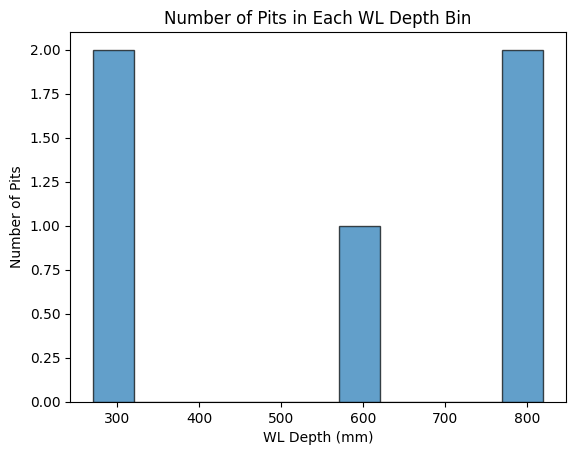

In [19]:
import matplotlib.pyplot as plt

# Bin wl depths according to 10 mm intervals
wl_depths = df["WL_Depth"]
max_wl_depth = max(wl_depths)
min_wl_depth = min(wl_depths)

# Create bins
bin_width = 50
bins = np.arange(min_wl_depth, max_wl_depth + bin_width, bin_width)

# Use matplotlib's histogram which handles this automatically
plt.hist(wl_depths, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel("WL Depth (mm)")
plt.ylabel("Number of Pits")
plt.title("Number of Pits in Each WL Depth Bin")
plt.show()

In [20]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

wl_depths = df["WL_Depth"]
df = df[df["WL_Depth"] > discard_pits_with_wl_above]

### Coupled Criterion

In [21]:
# Plot cumulative distribution of coupled criterion
cc = df["coupled_criterion"][~np.isnan(df["coupled_criterion"])]
sorted_cc = np.sort(cc)
cdf = np.arange(1, len(sorted_cc) + 1) / len(sorted_cc)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_cc, y=cdf, mode="markers", name="Coupled Criterion", marker=dict(color="red")))
fig.update_layout(xaxis_title="Weight (kg)", yaxis_title="Cumulative Distribution")
fig.show()

In [22]:
from scipy import stats

# Fit a normal distribution to the data
params_norm = stats.norm.fit(cc)
cdf_values_norm = stats.norm.cdf(sorted_cc, *params_norm)

# Fit a log-normal distribution to the data
params_lognorm = stats.lognorm.fit(cc)
cdf_values_lognorm = stats.lognorm.cdf(sorted_cc, *params_lognorm)

# # Fit an exponential distribution to the data
# params_expon = stats.expon.fit(cc)
# cdf_values_expon = stats.expon.cdf(sorted_cc, *params_expon)

# Fit an Exponential Normal distribution to the data
params_exponnorm = stats.exponnorm.fit(cc)
cdf_values_exponnorm = stats.exponnorm.cdf(sorted_cc, *params_exponnorm)
print(params_exponnorm)


fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_cc, y=cdf_values_norm, mode="lines", name="Normal"))
fig.add_trace(go.Scatter(x=sorted_cc, y=cdf_values_lognorm, mode="lines", name="Lognormal"))
# fig.add_trace(go.Scatter(x=sorted_cc, y=cdf_values_expon, mode="lines", name="Exponential"))
fig.add_trace(go.Scatter(x=sorted_cc, y=cdf_values_exponnorm, mode="lines", name="Exponential Normal"))
fig.add_trace(go.Scatter(x=sorted_cc, y=cdf, mode="markers", name="Data"))
fig.show()


(np.float64(0.23210761049209755), np.float64(270.54660270370175), np.float64(130.80695897213792))


## Steady State Energy Release Rate

In [23]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Plot cumulative distribution of coupled criterion
sserr = df["sserr_result"][~np.isnan(df["sserr_result"])]
sorted_sserr = np.sort(sserr)
cdf = np.arange(1, len(sorted_sserr) + 1) / len(sorted_sserr)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf, mode="markers", name="SSERR", marker=dict(color="red")))
fig.update_layout(xaxis_title="SSERR", yaxis_title="Cumulative Distribution")
fig.show()


In [24]:
from scipy import stats

# # Fit a normal distribution to the data
# params_norm = stats.norm.fit(sserr)
# cdf_values_norm = stats.norm.cdf(sorted_sserr, *params_norm)

# Fit a log-normal distribution to the data
params_lognorm = stats.lognorm.fit(sserr)
cdf_values_lognorm = stats.lognorm.cdf(sorted_sserr, *params_lognorm)
print(params_lognorm)

# # Fit an exponential distribution to the data
# params_expon = stats.expon.fit(sserr)
# cdf_values_expon = stats.expon.cdf(sorted_sserr, *params_expon)

# Fit an Exponential Normal distribution to the data
params_exponnorm = stats.exponnorm.fit(sserr)
cdf_values_exponnorm = stats.exponnorm.cdf(sorted_sserr, *params_exponnorm)


fig = go.Figure()
# fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf_values_norm, mode="lines", name="Normal"))
fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf_values_lognorm, mode="lines", name="Lognormal"))
# fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf_values_expon, mode="lines", name="Exponential"))
fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf_values_exponnorm, mode="lines", name="Exponential Normal"))
fig.add_trace(go.Scatter(x=sorted_sserr, y=cdf, mode="markers", name="Data"))
fig.show()


(np.float64(14.74431973252262), np.float64(1.5063292246034234), np.float64(0.0013134888774882065))


## Max Stress

In [25]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Plot cumulative distribution of coupled criterion
max_stress = df["max_stress"][~np.isnan(df["max_stress"])]
sorted_max_stress = np.sort(max_stress)
cdf = np.arange(1, len(sorted_max_stress) + 1) / len(sorted_max_stress)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf, mode="markers", name="max_stress", marker=dict(color="red")))
fig.update_layout(xaxis_title="max_stress", yaxis_title="Cumulative Distribution")
fig.show()


In [26]:
from scipy import stats

# # Fit a normal distribution to the data
params_norm = stats.norm.fit(max_stress)
cdf_values_norm = stats.norm.cdf(sorted_max_stress, *params_norm)

# Fit a log-normal distribution to the data
params_lognorm = stats.lognorm.fit(max_stress)
cdf_values_lognorm = stats.lognorm.cdf(sorted_max_stress, *params_lognorm)
print(params_lognorm)

# # Fit an exponential distribution to the data
params_expon = stats.expon.fit(max_stress)
cdf_values_expon = stats.expon.cdf(sorted_max_stress, *params_expon)

# Fit an Exponential Normal distribution to the data
params_exponnorm = stats.exponnorm.fit(max_stress)
cdf_values_exponnorm = stats.exponnorm.cdf(sorted_max_stress, *params_exponnorm)


fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf_values_norm, mode="lines", name="Normal"))
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf_values_lognorm, mode="lines", name="Lognormal"))
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf_values_expon, mode="lines", name="Exponential"))
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf_values_exponnorm, mode="lines", name="Exponential Normal"))
fig.add_trace(go.Scatter(x=sorted_max_stress, y=cdf, mode="markers", name="Data"))
fig.show()


(np.float64(15.286187176070444), np.float64(0.004891971922020654), np.float64(1.4562369518572254e-05))


## Steady State S_xx (normalized)

In [27]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Plot cumulative distribution of coupled criterion
weight = np.arange(0, 600, 10)
ss_max_Sxx_norm = df["ss_max_Sxx_norm"][~np.isnan(df["ss_max_Sxx_norm"])]
sorted_ss_max_Sxx_norm = np.sort(ss_max_Sxx_norm)
cdf = np.arange(1, len(sorted_ss_max_Sxx_norm) + 1) / len(sorted_ss_max_Sxx_norm)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf, mode="markers", name="SS MAX SXX NORM", marker=dict(color="red")))
fig.update_layout(xaxis_title="SS MAX SXX NORM", yaxis_title="Cumulative Distribution")
fig.show()


In [28]:
from scipy import stats

# # Fit a normal distribution to the data
params_norm = stats.norm.fit(ss_max_Sxx_norm)
cdf_values_norm = stats.norm.cdf(sorted_ss_max_Sxx_norm, *params_norm)

# Fit a log-normal distribution to the data
params_lognorm = stats.lognorm.fit(ss_max_Sxx_norm)
cdf_values_lognorm = stats.lognorm.cdf(sorted_ss_max_Sxx_norm, *params_lognorm)

# # Fit an exponential distribution to the data
params_expon = stats.expon.fit(ss_max_Sxx_norm)
cdf_values_expon = stats.expon.cdf(sorted_ss_max_Sxx_norm, *params_expon)

# Fit an Exponential Normal distribution to the data
params_exponnorm = stats.exponnorm.fit(ss_max_Sxx_norm)
cdf_values_exponnorm = stats.exponnorm.cdf(sorted_ss_max_Sxx_norm, *params_exponnorm)
print(params_exponnorm)


fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf_values_norm, mode="lines", name="Normal"))
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf_values_lognorm, mode="lines", name="Lognormal"))
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf_values_expon, mode="lines", name="Exponential"))
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf_values_exponnorm, mode="lines", name="Exponential Normal"))
fig.add_trace(go.Scatter(x=sorted_ss_max_Sxx_norm, y=cdf, mode="markers", name="Data"))
fig.show()


(np.float64(0.0007154404695858671), np.float64(2.055303368589943), np.float64(0.3093914148350353))


## Slab Tensile Criterion

In [29]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Plot cumulative distribution of coupled criterion
weight = np.arange(0, 600, 10)
slab_tensile_criterion = df["slab_tensile_criterion"][~np.isnan(df["slab_tensile_criterion"])]
sorted_slab_tensile_criterion = np.sort(slab_tensile_criterion)
cdf = np.arange(1, len(sorted_slab_tensile_criterion) + 1) / len(sorted_slab_tensile_criterion)

fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf, mode="markers", name="SLAB TENSILE CRITERION", marker=dict(color="red")))
fig.update_layout(xaxis_title="SLAB TENSILE CRITERION", yaxis_title="Cumulative Distribution")
fig.show()


In [30]:
from scipy import stats

# # Fit a normal distribution to the data
params_norm = stats.norm.fit(slab_tensile_criterion)
cdf_values_norm = stats.norm.cdf(sorted_slab_tensile_criterion, *params_norm)

# Fit a log-normal distribution to the data
params_lognorm = stats.lognorm.fit(slab_tensile_criterion)
cdf_values_lognorm = stats.lognorm.cdf(sorted_slab_tensile_criterion, *params_lognorm)
print(params_lognorm)

# # Fit an exponential distribution to the data
params_expon = stats.expon.fit(slab_tensile_criterion)
cdf_values_expon = stats.expon.cdf(sorted_slab_tensile_criterion, *params_expon)

# Fit an Exponential Normal distribution to the data
params_exponnorm = stats.exponnorm.fit(slab_tensile_criterion)
cdf_values_exponnorm = stats.exponnorm.cdf(sorted_slab_tensile_criterion, *params_exponnorm)


fig = go.Figure()
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf_values_norm, mode="lines", name="Normal"))
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf_values_lognorm, mode="lines", name="Lognormal"))
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf_values_expon, mode="lines", name="Exponential"))
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf_values_exponnorm, mode="lines", name="Exponential Normal"))
fig.add_trace(go.Scatter(x=sorted_slab_tensile_criterion, y=cdf, mode="markers", name="Data"))
fig.show()


(np.float64(14.795437685972663), np.float64(0.09793814432989689), np.float64(9.776645990181719e-05))
